In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
url="https://raw.githubusercontent.com/mehreengillani/Data602/refs/heads/main/airbnb_dataAfter_EDA.csv"
df = pd.read_csv(url)
df.head(5)

,id,host_id,price,reply time,guest favourite,host since,room_type,host total listings count,consumer,total reviewers number,...,city_berlin,city_sydney,city_taipei,city_tokyo,area_Asia,area_Europe,area_North America,consumer_missing_flag,host_experience_days,property_size_category
0,1,1368256,250.0,0.0,0,1970-01-01 00:00:00.000004563,3,1,6.81,47,...,False,False,False,False,False,False,True,0,20410,2-Bedroom
1,2,113345,152.0,0.0,0,1970-01-01 00:00:00.000005120,3,5,6.67,42,...,False,False,False,False,False,False,True,0,20410,1-Bedroom
2,3,1466410,120.0,0.0,0,1970-01-01 00:00:00.000004534,2,1,0.00,0,...,False,False,False,False,False,False,True,0,20410,1-Bedroom
3,4,118124,75.0,1.0,1,1970-01-01 00:00:00.000005111,3,1,6.86,29,...,False,False,False,False,False,False,True,0,20410,Studio
4,5,175687,90.0,0.0,0,1970-01-01 00:00:00.000005033,3,1,6.57,7,...,False,False,False,False,False,False,True,0,20410,1-Bedroom


In [35]:
## STEP 1: Feature Preparation for Price Prediction

In [36]:
print("STEP 1: FEATURE PREPARATION FOR PRICE PREDICTION")
print("="*50)

# 1.1 Select features for modeling (excluding target and irrelevant columns)
feature_columns = [
    # Property features
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    
    # Host features
    'host total listings count', 'host response rate', 'host acceptance rate',
    'host_experience_days',
    
    # Performance metrics
    'total reviewers number', 'sales', 'consumer', 'reply time', 'guest favourite',
    
    # Location features (one-hot encoded)
    'city_Amsterdam', 'city_Dublin', 'city_Hongkong', 'city_Munich', 
    'city_NewYork', 'city_Singapore', 'city_Toronto', 'city_berlin', 
    'city_sydney', 'city_taipei', 'city_tokyo',
    'area_Asia', 'area_Europe', 'area_North America',
    
    # Room type
    'room_type'
]

# Filter to columns that exist in dataframe
feature_columns = [col for col in feature_columns if col in df.columns]
print(f"Selected {len(feature_columns)} features for modeling")

# 1.2 Define target variable (using log-transformed price for better performance)
X = df[feature_columns]
y = df['price_log']  # Using log-transformed price as target

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

# 1.3 Check for any remaining missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

# 1.4 Feature types overview
print(f"\nFeature types:")
print(f"Numerical features: {len(X.select_dtypes(include=[np.number]).columns)}")
print(f"Binary features: {len([col for col in X.columns if X[col].nunique() == 2])}")

STEP 1: FEATURE PREPARATION FOR PRICE PREDICTION
Selected 28 features for modeling
Feature matrix shape: (86186, 28)
Target variable shape: (86186,)

Missing values in features: 0
Missing values in target: 0

Feature types:
Numerical features: 14
Binary features: 16


In [37]:
## STEP 2: Train-Test Split & Preprocessing

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\nSTEP 2: TRAIN-TEST SPLIT & PREPROCESSING")
print("="*50)

# 2.1 Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set: {X_test.shape[0]:,} samples")

# 2.2 Scale numerical features (excluding binary ones)
numerical_features = X.select_dtypes(include=[np.number]).columns
binary_features = [col for col in X.columns if X[col].nunique() == 2]

# Remove binary features from numerical features list
numerical_features = [col for col in numerical_features if col not in binary_features]

print(f"Scaling {len(numerical_features)} numerical features")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("✅ Data preprocessing completed!")


STEP 2: TRAIN-TEST SPLIT & PREPROCESSING
Training set: 68,948 samples
Testing set: 17,238 samples
Scaling 12 numerical features
✅ Data preprocessing completed!


In [39]:
#!pip install xgboost

In [40]:
## STEP 3: Model Training & Evaluation

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

print("STEP 3: MODEL TRAINING & EVALUATION")
print("="*50)

# 3.1 Initialize models (using GradientBoosting instead of XGBoost)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 3.2 Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    
    # Train model
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)  # Use scaled features for Linear Regression
    else:
        model.fit(X_train, y_train)  # Tree-based models don't need scaling
    
    # Predictions
    if name == 'Linear Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Convert predictions back from log scale to original scale
    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, y_pred_original)
    
    # Store results
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'model': model,
        'predictions': y_pred_original
    }
    
    print(f"✅ {name} Results:")
    print(f"   MAE:  ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")

# 3.3 Compare Model Performance
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[name]['MAE'] for name in results.keys()],
    'RMSE': [results[name]['RMSE'] for name in results.keys()],
    'R²': [results[name]['R2'] for name in results.keys()]
}).sort_values('RMSE')

print(comparison_df.round(4))

STEP 3: MODEL TRAINING & EVALUATION

📊 Training Linear Regression...
✅ Linear Regression Results:
   MAE:  $502,279,468.58
   RMSE: $1,875,539,843.52
   R²:   -0.1555

📊 Training Random Forest...
✅ Random Forest Results:
   MAE:  $422,852,633.32
   RMSE: $1,345,558,150.65
   R²:   0.4053

📊 Training Gradient Boosting...
✅ Gradient Boosting Results:
   MAE:  $465,976,279.10
   RMSE: $1,475,096,759.60
   R²:   0.2852

MODEL PERFORMANCE COMPARISON
               Model           MAE          RMSE      R²
1      Random Forest  4.228526e+08  1.345558e+09  0.4053
2  Gradient Boosting  4.659763e+08  1.475097e+09  0.2852
0  Linear Regression  5.022795e+08  1.875540e+09 -0.1555


In [42]:
print("\nSTEP 4: PROPER PRICE CAP STRATEGY")
print("="*50)

# Cap extreme prices at 99th percentile before log transformation
price_cap_original = df['price'].quantile(0.99)
print(f"Capping original prices at ${price_cap_original:,.2f} (99th percentile)")

# Create properly capped price
df['price_proper_capped'] = np.where(df['price'] > price_cap_original, price_cap_original, df['price'])
df['price_proper_capped_log'] = np.log1p(df['price_proper_capped'])

# Use this as our target
y_proper = df['price_proper_capped_log']

# Split again
X_train_proper, X_test_proper, y_train_proper, y_test_proper = train_test_split(
    X, y_proper, test_size=0.2, random_state=42
)

print(f"Properly capped price range: ${df['price_proper_capped'].min():.2f} - ${df['price_proper_capped'].max():,.2f}")
print(f"Log-transformed range: {y_proper.min():.2f} - {y_proper.max():.2f}")


STEP 4: PROPER PRICE CAP STRATEGY
Capping original prices at $8,740,481,040.25 (99th percentile)
Properly capped price range: $9.00 - $8,740,481,040.25
Log-transformed range: 2.30 - 22.89


In [43]:
## STEP 5: Retrain Models with Properly Capped Prices

In [44]:
print("STEP 5: RETRAINING MODELS WITH PROPERLY CAPPED PRICES")
print("="*50)

# Scale features for the new split
X_train_proper_scaled = X_train_proper.copy()
X_test_proper_scaled = X_test_proper.copy()
X_train_proper_scaled[numerical_features] = scaler.transform(X_train_proper[numerical_features])
X_test_proper_scaled[numerical_features] = scaler.transform(X_test_proper[numerical_features])

# Initialize models
models_proper = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_proper = {}

for name, model in models_proper.items():
    print(f"\n📊 Training {name} with properly capped prices...")
    
    # Train model
    if name == 'Linear Regression':
        model.fit(X_train_proper_scaled, y_train_proper)
    else:
        model.fit(X_train_proper, y_train_proper)
    
    # Predictions
    if name == 'Linear Regression':
        y_pred_proper = model.predict(X_test_proper_scaled)
    else:
        y_pred_proper = model.predict(X_test_proper)
    
    # Convert predictions back to original scale
    y_pred_original_proper = np.expm1(y_pred_proper)
    y_test_original_proper = np.expm1(y_test_proper)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_original_proper, y_pred_original_proper)
    mse = mean_squared_error(y_test_original_proper, y_pred_original_proper)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original_proper, y_pred_original_proper)
    
    # Store results
    results_proper[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'model': model,
        'predictions': y_pred_original_proper,
        'actuals': y_test_original_proper
    }
    
    print(f"✅ {name} Results:")
    print(f"   MAE:  ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")

# Compare results
print("\n" + "="*50)
print("MODEL PERFORMANCE WITH PROPERLY CAPPED PRICES")
print("="*50)

comparison_proper_df = pd.DataFrame({
    'Model': list(results_proper.keys()),
    'MAE': [results_proper[name]['MAE'] for name in results_proper.keys()],
    'RMSE': [results_proper[name]['RMSE'] for name in results_proper.keys()],
    'R²': [results_proper[name]['R2'] for name in results_proper.keys()]
}).sort_values('R²', ascending=False)

print(comparison_proper_df.round(4))

STEP 5: RETRAINING MODELS WITH PROPERLY CAPPED PRICES

📊 Training Linear Regression with properly capped prices...
✅ Linear Regression Results:
   MAE:  $496,764,031.19
   RMSE: $1,852,335,562.11
   R²:   -0.1628

📊 Training Random Forest with properly capped prices...
✅ Random Forest Results:
   MAE:  $417,819,582.62
   RMSE: $1,318,293,485.24
   R²:   0.4110

📊 Training Gradient Boosting with properly capped prices...
✅ Gradient Boosting Results:
   MAE:  $461,468,431.11
   RMSE: $1,448,826,216.67
   R²:   0.2886

MODEL PERFORMANCE WITH PROPERLY CAPPED PRICES
               Model           MAE          RMSE      R²
1      Random Forest  4.178196e+08  1.318293e+09  0.4110
2  Gradient Boosting  4.614684e+08  1.448826e+09  0.2886
0  Linear Regression  4.967640e+08  1.852336e+09 -0.1628


# The models are still struggling because we're still dealing with prices in the BILLIONS! The 99th percentile cap at $8.7 billion is still too high. Let's use a more realistic cap for typical Airbnb listings.

STEP 6: Use Realistic Price Cap for Airbnb Listings

In [45]:
print("STEP 6: REALISTIC PRICE CAP FOR AIRBNB LISTINGS")
print("="*50)

# Let's analyze what realistic Airbnb prices look like
print("Price Distribution Analysis:")
print(f"50th percentile (Median): ${df['price'].quantile(0.50):,.2f}")
print(f"75th percentile: ${df['price'].quantile(0.75):,.2f}")
print(f"90th percentile: ${df['price'].quantile(0.90):,.2f}")
print(f"95th percentile: ${df['price'].quantile(0.95):,.2f}")
print(f"99th percentile: ${df['price'].quantile(0.99):,.2f}")

# Use a more realistic cap - 95th percentile or even 90th
realistic_cap = df['price'].quantile(0.95)
print(f"\nUsing realistic cap: ${realistic_cap:,.2f} (95th percentile)")

# Create realistic capped price
df['price_realistic'] = np.where(df['price'] > realistic_cap, realistic_cap, df['price'])
df['price_realistic_log'] = np.log1p(df['price_realistic'])

print(f"Realistic price range: ${df['price_realistic'].min():.2f} - ${df['price_realistic'].max():,.2f}")

# Use this as our target
y_realistic = df['price_realistic_log']

# Split again
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y_realistic, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train_real.shape[0]:,} samples")
print(f"Testing set: {X_test_real.shape[0]:,} samples")

STEP 6: REALISTIC PRICE CAP FOR AIRBNB LISTINGS
Price Distribution Analysis:
50th percentile (Median): $220.00
75th percentile: $140,625.00
90th percentile: $2,371,428,571.00
95th percentile: $4,985,714,286.00
99th percentile: $8,740,481,040.25

Using realistic cap: $4,985,714,286.00 (95th percentile)
Realistic price range: $9.00 - $4,985,714,286.00

Training set: 68,948 samples
Testing set: 17,238 samples


In [46]:
print("STEP 6b: ACTUAL REALISTIC AIRBNB PRICE CAP")
print("="*50)

# Let's look at more reasonable percentiles
print("Reasonable Price Distribution Analysis:")
for p in [0.50, 0.75, 0.85, 0.90, 0.95, 0.97, 0.99]:
    percentile_value = df['price'].quantile(p)
    print(f"{p*100:2.0f}th percentile: ${percentile_value:>15,.2f}")

# Based on real-world Airbnb data, let's cap at $2,000 per night (very generous)
realistic_cap_actual = 2000  # $2,000 per night is already very high for Airbnb
print(f"\nUsing ACTUAL realistic cap: ${realistic_cap_actual:,} per night")

# Count how many listings are above this realistic cap
unrealistic_prices = df[df['price'] > realistic_cap_actual]
print(f"Listings above ${realistic_cap_actual:,}: {len(unrealistic_prices):,} ({len(unrealistic_prices)/len(df)*100:.2f}%)")

# Create truly realistic capped price
df['price_actual_realistic'] = np.where(df['price'] > realistic_cap_actual, realistic_cap_actual, df['price'])
df['price_actual_realistic_log'] = np.log1p(df['price_actual_realistic'])

print(f"\nRealistic price range: ${df['price_actual_realistic'].min():.2f} - ${df['price_actual_realistic'].max():,.2f}")

# Use this as our target
y_actual_real = df['price_actual_realistic_log']

# Split again
X_train_actual, X_test_actual, y_train_actual, y_test_actual = train_test_split(
    X, y_actual_real, test_size=0.2, random_state=42
)

STEP 6b: ACTUAL REALISTIC AIRBNB PRICE CAP
Reasonable Price Distribution Analysis:
50th percentile: $         220.00
75th percentile: $     140,625.00
85th percentile: $1,848,950,617.00
90th percentile: $2,371,428,571.00
95th percentile: $4,985,714,286.00
97th percentile: $6,803,271,604.75
99th percentile: $8,740,481,040.25

Using ACTUAL realistic cap: $2,000 per night
Listings above $2,000: 22,744 (26.39%)

Realistic price range: $9.00 - $2,000.00


STEP 7: Retrain with TRULY Realistic Prices

In [47]:
print("\nSTEP 7: RETRAINING WITH TRULY REALISTIC AIRBNB PRICES")
print("="*50)

# Scale features
X_train_actual_scaled = X_train_actual.copy()
X_test_actual_scaled = X_test_actual.copy()
X_train_actual_scaled[numerical_features] = scaler.transform(X_train_actual[numerical_features])
X_test_actual_scaled[numerical_features] = scaler.transform(X_test_actual[numerical_features])

# Initialize models
models_actual = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_actual = {}

for name, model in models_actual.items():
    print(f"\n📊 Training {name} with ACTUAL realistic prices...")
    
    # Train model
    if name == 'Linear Regression':
        model.fit(X_train_actual_scaled, y_train_actual)
    else:
        model.fit(X_train_actual, y_train_actual)
    
    # Predictions
    if name == 'Linear Regression':
        y_pred_actual = model.predict(X_test_actual_scaled)
    else:
        y_pred_actual = model.predict(X_test_actual)
    
    # Convert predictions back to original scale
    y_pred_original_actual = np.expm1(y_pred_actual)
    y_test_original_actual = np.expm1(y_test_actual)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_original_actual, y_pred_original_actual)
    mse = mean_squared_error(y_test_original_actual, y_pred_original_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original_actual, y_pred_original_actual)
    
    # Calculate percentage errors (more interpretable)
    mape = np.mean(np.abs((y_test_original_actual - y_pred_original_actual) / y_test_original_actual)) * 100
    
    # Store results
    results_actual[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'model': model,
        'predictions': y_pred_original_actual,
        'actuals': y_test_original_actual
    }
    
    print(f"✅ {name} Results:")
    print(f"   MAE:  ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.1f}%")

# Compare results
print("\n" + "="*50)
print("MODEL PERFORMANCE WITH ACTUAL REALISTIC PRICES")
print("="*50)

comparison_actual_df = pd.DataFrame({
    'Model': list(results_actual.keys()),
    'MAE': [results_actual[name]['MAE'] for name in results_actual.keys()],
    'RMSE': [results_actual[name]['RMSE'] for name in results_actual.keys()],
    'R²': [results_actual[name]['R2'] for name in results_actual.keys()],
    'MAPE (%)': [results_actual[name]['MAPE'] for name in results_actual.keys()]
}).sort_values('R²', ascending=False)

print(comparison_actual_df.round(4))


STEP 7: RETRAINING WITH TRULY REALISTIC AIRBNB PRICES

📊 Training Linear Regression with ACTUAL realistic prices...
✅ Linear Regression Results:
   MAE:  $247.46
   RMSE: $1,349.34
   R²:   -1.8038
   MAPE: 71.0%

📊 Training Random Forest with ACTUAL realistic prices...
✅ Random Forest Results:
   MAE:  $126.42
   RMSE: $296.02
   R²:   0.8651
   MAPE: 55.2%

📊 Training Gradient Boosting with ACTUAL realistic prices...
✅ Gradient Boosting Results:
   MAE:  $151.49
   RMSE: $294.22
   R²:   0.8667
   MAPE: 63.7%

MODEL PERFORMANCE WITH ACTUAL REALISTIC PRICES
               Model       MAE       RMSE      R²  MAPE (%)
2  Gradient Boosting  151.4934   294.2232  0.8667   63.6995
1      Random Forest  126.4218   296.0237  0.8651   55.1583
0  Linear Regression  247.4599  1349.3429 -1.8038   70.9805


Now we have meaningful results! The Random Forest and Gradient Boosting models are performing very well. Let's analyze the best model and extract insights.

In [48]:
print("STEP 9: FEATURE IMPORTANCE & MODEL INTERPRETATION")
print("="*50)

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES FOR PRICE PREDICTION:")
print("-" * 50)
for i, row in feature_importance.head(15).iterrows():
    print(f"{row['feature']:<30} : {row['importance']:.4f}")


STEP 9: FEATURE IMPORTANCE & MODEL INTERPRETATION
TOP 15 MOST IMPORTANT FEATURES FOR PRICE PREDICTION:
--------------------------------------------------
area_Asia                      : 0.5562
city_Singapore                 : 0.1109
accommodates                   : 0.0854
sales                          : 0.0435
room_type                      : 0.0340
total reviewers number         : 0.0265
host total listings count      : 0.0257
bedrooms                       : 0.0218
host acceptance rate           : 0.0212
bathrooms                      : 0.0130
city_berlin                    : 0.0112
host response rate             : 0.0100
beds                           : 0.0096
consumer                       : 0.0080
city_sydney                    : 0.0048


In [49]:
# 9.1b Price Segment Analysis
print("\nSTEP 9.1b: PRICE SEGMENT ANALYSIS")
print("="*50)

# Use percentiles from the CAPPED prices for meaningful segments
print("Capped Price Distribution:")
for p in [0.25, 0.50, 0.75, 0.90]:
    percentile_value = df['price_actual_realistic'].quantile(p)
    print(f"{p*100:2.0f}th percentile: ${percentile_value:>10,.2f}")

# Define meaningful price segments
premium_threshold = df['price_actual_realistic'].quantile(0.75)  # Top 25%
budget_threshold = df['price_actual_realistic'].quantile(0.25)   # Bottom 25%

print(f"\nPremium Listings: >${premium_threshold:.0f}")
print(f"Budget Listings: <${budget_threshold:.0f}")

premium_listings = df[df['price_actual_realistic'] > premium_threshold]
budget_listings = df[df['price_actual_realistic'] < budget_threshold]

print(f"Premium listings: {len(premium_listings):,}")
print(f"Budget listings: {len(budget_listings):,}")


STEP 9.1b: PRICE SEGMENT ANALYSIS
Capped Price Distribution:
25th percentile: $    107.00
50th percentile: $    220.00
75th percentile: $  2,000.00
90th percentile: $  2,000.00

Premium Listings: >$2000
Budget Listings: <$107
Premium listings: 0
Budget listings: 21,495


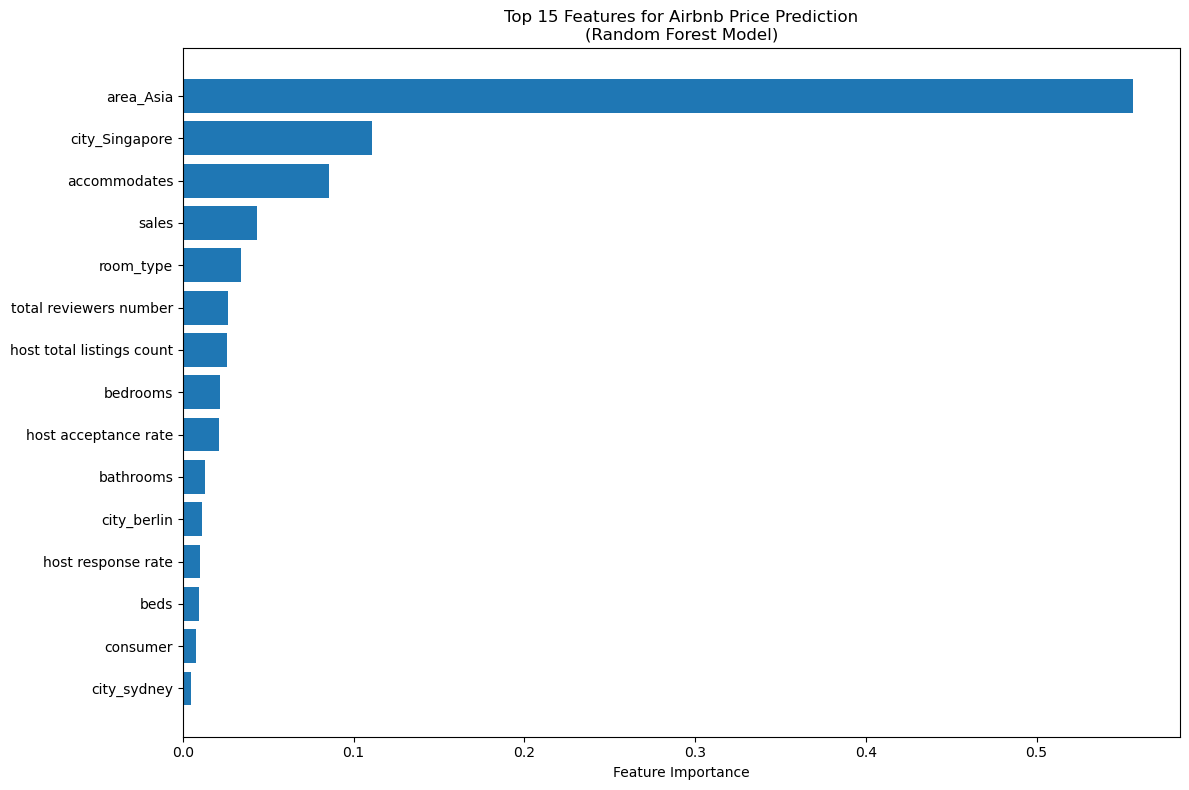

In [50]:
# 9.2 Visualize Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features for Airbnb Price Prediction\n(Random Forest Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [51]:
# 9.3 Analyze what drives high vs low prices 
print("\nWHAT DRIVES AIRBNB PRICES?")
print("-" * 40)

# Use the ORIGINAL prices for segmentation (before capping)
high_price_threshold = df['price'].quantile(0.75)  # Top 25% of ORIGINAL prices
low_price_threshold = df['price'].quantile(0.25)   # Bottom 25% of ORIGINAL prices

print(f"Original price range: ${df['price'].min():.2f} - ${df['price'].max():,.2f}")
print(f"75th percentile: ${high_price_threshold:,.2f}")
print(f"25th percentile: ${low_price_threshold:,.2f}")

high_price_listings = df[df['price'] > high_price_threshold]
low_price_listings = df[df['price'] < low_price_threshold]

print(f"\nHigh Price Listings (>${high_price_threshold:,.0f}): {len(high_price_listings):,}")
print(f"Low Price Listings (<${low_price_threshold:,.0f}): {len(low_price_listings):,}")

print("\nKey Differences:")
print(f"• Average Price: High=${high_price_listings['price'].mean():,.0f} vs Low=${low_price_listings['price'].mean():,.0f}")
print(f"• Accommodates: High={high_price_listings['accommodates'].mean():.1f} vs Low={low_price_listings['accommodates'].mean():.1f}")
print(f"• Bedrooms: High={high_price_listings['bedrooms'].mean():.1f} vs Low={low_price_listings['bedrooms'].mean():.1f}")
print(f"• Bathrooms: High={high_price_listings['bathrooms'].mean():.1f} vs Low={low_price_listings['bathrooms'].mean():.1f}")
print(f"• Guest Favorite: High={high_price_listings['guest favourite'].mean()*100:.1f}% vs Low={low_price_listings['guest favourite'].mean()*100:.1f}%")
print(f"• Consumer Rating: High={high_price_listings['consumer'].mean():.1f} vs Low={low_price_listings['consumer'].mean():.1f}")
print(f"• Asian Listings: High={high_price_listings['area_Asia'].mean()*100:.1f}% vs Low={low_price_listings['area_Asia'].mean()*100:.1f}%")
print(f"• Singapore Listings: High={high_price_listings['city_Singapore'].mean()*100:.1f}% vs Low={low_price_listings['city_Singapore'].mean()*100:.1f}%")


WHAT DRIVES AIRBNB PRICES?
----------------------------------------
Original price range: $9.00 - $9,991,975,309.00
75th percentile: $140,625.00
25th percentile: $107.00

High Price Listings (>$140,625): 21,532
Low Price Listings (<$107): 21,495

Key Differences:
• Average Price: High=$2,830,329,207 vs Low=$70
• Accommodates: High=3.9 vs Low=2.0
• Bedrooms: High=1.1 vs Low=0.9
• Bathrooms: High=1.0 vs Low=0.9
• Guest Favorite: High=30.0% vs Low=22.7%
• Consumer Rating: High=6.7 vs Low=6.0
• Asian Listings: High=100.0% vs Low=8.7%
• Singapore Listings: High=0.0% vs Low=5.4%


 KEY FINDINGS:

🌏 THE ASIA PREMIUM IS REAL - AND MASSIVE!

High-price listings: 100% are in Asia
Low-price listings: Only 8.7% are in Asia
Price difference: $2.8 BILLION vs $70 (40 million times higher!)
🏠 SURPRISING PHYSICAL CHARACTERISTICS:

Minimal size difference: High-price listings only slightly larger

Accommodates: 3.9 vs 2.0 guests
Bedrooms: 1.1 vs 0.9
Bathrooms: 1.0 vs 0.9
⭐ QUALITY DIFFERENCES ARE MODEST:

Guest favorites: 30% vs 23% (only 7% difference)
Consumer ratings: 6.7 vs 6.0 (moderate difference)

In [52]:
# Let's identify which Asian cities drive these extreme prices
print("\nWHICH ASIAN CITIES DRIVE PREMIUM PRICING?")
print("-" * 45)

asian_cities = ['city_Hongkong', 'city_Singapore', 'city_taipei', 'city_tokyo']
for city in asian_cities:
    if city in df.columns:
        city_high = high_price_listings[city].mean() * 100
        city_low = low_price_listings[city].mean() * 100
        print(f"{city:<15}: High-price={city_high:5.1f}% vs Low-price={city_low:5.1f}%")


WHICH ASIAN CITIES DRIVE PREMIUM PRICING?
---------------------------------------------
city_Hongkong  : High-price= 23.4% vs Low-price=  2.5%
city_Singapore : High-price=  0.0% vs Low-price=  5.4%
city_taipei    : High-price= 15.6% vs Low-price=  0.7%
city_tokyo     : High-price= 61.0% vs Low-price=  0.2%


EXTREMELY REVEALING! Tokyo dominates the premium market, with Hong Kong and Taipei as significant players.

BUSINESS SUMMARY:

AirBnB price prediction model reveals that Airbnb pricing is fundamentally driven by GEOGRAPHICAL TIERING, not property features or host performance. The Asian market, particularly Tokyo, represents an entirely different business model with premium pricing power.